# Load from Weather Data

## Imports

In [1]:
import pandas as pd 
import numpy as np
import sqlite3
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from datetime import date, timedelta
from pandas.tseries.offsets import DateOffset
from pandas import Timestamp
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

## Setup

### Load Data

In [9]:
weather_db_path = "1. Weather/weather_data_2.db"
weather_conn = sqlite3.connect(weather_db_path)

# List tables
weather_tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", weather_conn)
print("Weather DB tables:", weather_tables)

# Pull only rows where date > 2012-01-01
weather = pd.read_sql("""
    SELECT *
    FROM system_weather_hourly
    WHERE date > '2012-01-01'
""", weather_conn)

weather_conn.close()

print(weather.head())


Weather DB tables:                             name
0                 hourly_weather
1          system_weather_hourly
2   system_weather_hourly_minus6
3   system_weather_hourly_minus5
4   system_weather_hourly_minus4
5   system_weather_hourly_minus3
6   system_weather_hourly_minus2
7   system_weather_hourly_minus1
8    system_weather_hourly_plus1
9    system_weather_hourly_plus2
10   system_weather_hourly_plus3
11   system_weather_hourly_plus4
12   system_weather_hourly_plus5
13   system_weather_hourly_plus6
                        date  system_max_thi
0  2012-01-01 00:00:00+00:00         52.8134
1  2012-01-01 01:00:00+00:00         51.4634
2  2012-01-01 02:00:00+00:00         50.4734
3  2012-01-01 03:00:00+00:00         49.4834
4  2012-01-01 04:00:00+00:00         48.4034


In [10]:
# --- Load PJM load data ---
load_db_path = "2. Load/pjm_hourly_load.db"
load_conn = sqlite3.connect(load_db_path)

# List tables in the database to see what to load
load_tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", load_conn)

# Replace 'pjm_load' with the table you actually want
load_df = pd.read_sql("SELECT * FROM pjm_hourly_load;", load_conn)

load_conn.close()

print(load_df.head())


  datetime_beginning_ept         mw  year
0    2012-01-01 00:00:00  74833.099  2012
1    2012-01-01 01:00:00  72482.246  2012
2    2012-01-01 02:00:00  70730.564  2012
3    2012-01-01 03:00:00  69886.051  2012
4    2012-01-01 04:00:00  69931.389  2012


### Merge

In [11]:
print(weather.head())

load_df['date'] = pd.to_datetime(load_df['datetime_beginning_ept'])
weather['date'] = pd.to_datetime(weather['date'])
weather['date'] = weather['date'].dt.tz_localize(None)


# Then filter
weather = weather[weather['date'].isin(load_df['date'])].reset_index(drop=True)


# Merge
merged_df = pd.merge(load_df, weather[['date', 'system_max_thi']],
                     on='date', how='left')
merged_df.rename(columns={'system_max_thi': 'thi'}, inplace=True)

print(merged_df.head())

                        date  system_max_thi
0  2012-01-01 00:00:00+00:00         52.8134
1  2012-01-01 01:00:00+00:00         51.4634
2  2012-01-01 02:00:00+00:00         50.4734
3  2012-01-01 03:00:00+00:00         49.4834
4  2012-01-01 04:00:00+00:00         48.4034
  datetime_beginning_ept         mw  year                date      thi
0    2012-01-01 00:00:00  74833.099  2012 2012-01-01 00:00:00  52.8134
1    2012-01-01 01:00:00  72482.246  2012 2012-01-01 01:00:00  51.4634
2    2012-01-01 02:00:00  70730.564  2012 2012-01-01 02:00:00  50.4734
3    2012-01-01 03:00:00  69886.051  2012 2012-01-01 03:00:00  49.4834
4    2012-01-01 04:00:00  69931.389  2012 2012-01-01 04:00:00  48.4034


In [12]:
# Create day and month columns
merged_df['month'] = merged_df['date'].dt.month
merged_df['weekday'] = merged_df['date'].dt.day_name()
merged_df = merged_df[merged_df['thi'].notna()]

print(merged_df)

       datetime_beginning_ept         mw  year                date        thi  \
0         2012-01-01 00:00:00  74833.099  2012 2012-01-01 00:00:00  52.813400   
1         2012-01-01 01:00:00  72482.246  2012 2012-01-01 01:00:00  51.463400   
2         2012-01-01 02:00:00  70730.564  2012 2012-01-01 02:00:00  50.473400   
3         2012-01-01 03:00:00  69886.051  2012 2012-01-01 03:00:00  49.483400   
4         2012-01-01 04:00:00  69931.389  2012 2012-01-01 04:00:00  48.403400   
...                       ...        ...   ...                 ...        ...   
121627    2025-11-15 19:00:00  85509.965  2025 2025-11-15 19:00:00  69.806254   
121628    2025-11-15 20:00:00  83783.025  2025 2025-11-15 20:00:00  70.134280   
121629    2025-11-15 21:00:00  81556.951  2025 2025-11-15 21:00:00  70.000934   
121630    2025-11-15 22:00:00  78597.620  2025 2025-11-15 22:00:00  68.898210   
121631    2025-11-15 23:00:00  75372.506  2025 2025-11-15 23:00:00  67.880758   

        month   weekday  
0

### Dummy variables

#### Week and Month

In [13]:
# ----- Month and Weekday -----
weekday_dummies = pd.get_dummies(merged_df['weekday'], prefix='w', drop_first=True)

# --- Month Dummies (for regression) ---
# Drop first month to avoid multicollinearity
month_dummies = pd.get_dummies(merged_df['month'], prefix='m', drop_first=True)

# --- Month Walk Variables (cumulative trend through the year) ---
# Keep all 12 months here, do NOT drop first
month_walk_dummies = pd.get_dummies(merged_df['month'], prefix='m', drop_first=False)
month_walk = month_walk_dummies.cumsum(axis=1)
month_walk.columns = ['m1_w', 'm2_w', 'm3_w', 'm4_w', 'm5_w', 'm6_w',
                      'm7_w', 'm8_w', 'm9_w', 'm10_w', 'm11_w', 'm12_w']

# --- Merge into main dataframe ---
merged_df = pd.concat([merged_df, month_dummies, month_walk, weekday_dummies], axis=1)
print(merged_df.head())


  datetime_beginning_ept         mw  year                date      thi  month  \
0    2012-01-01 00:00:00  74833.099  2012 2012-01-01 00:00:00  52.8134      1   
1    2012-01-01 01:00:00  72482.246  2012 2012-01-01 01:00:00  51.4634      1   
2    2012-01-01 02:00:00  70730.564  2012 2012-01-01 02:00:00  50.4734      1   
3    2012-01-01 03:00:00  69886.051  2012 2012-01-01 03:00:00  49.4834      1   
4    2012-01-01 04:00:00  69931.389  2012 2012-01-01 04:00:00  48.4034      1   

  weekday    m_2    m_3    m_4  ...  m9_w  m10_w  m11_w  m12_w  w_Monday  \
0  Sunday  False  False  False  ...     1      1      1      1     False   
1  Sunday  False  False  False  ...     1      1      1      1     False   
2  Sunday  False  False  False  ...     1      1      1      1     False   
3  Sunday  False  False  False  ...     1      1      1      1     False   
4  Sunday  False  False  False  ...     1      1      1      1     False   

   w_Saturday  w_Sunday  w_Thursday  w_Tuesday  w_Wednes

#### Holidays

##### Initial Declaration

In [14]:

# ----- Holidays -----
holidays = ['MLK', 'PresDay', 'GoodFri', 'MemDay', 'July4', 
            'LaborDay', 'Thanks', 'FriAThanks', 
            'XmasEve', 'XmasDay', 'NYEve', 'NYDay', 'SpringDST', 'FallDST']

for h in holidays:
    merged_df[h] = 0    # you will set these to 1 based on date logic

merged_df['WkdayBeforeHol'] = 0
merged_df['WkdayAfterHol'] = 0
merged_df['WkAfterNewYear'] = 0
merged_df['WkBeforeXMas'] = 0


##### Helper Functions

In [15]:
def nth_weekday_of_month(year, month, weekday, n):
    """weekday: Monday=0 ... Sunday=6; n=1 -> first, n=3 -> third"""
    d = date(year, month, 1)
    shift = (weekday - d.weekday()) % 7
    d = d + timedelta(days=shift)
    return d + timedelta(weeks=n-1)

def last_weekday_of_month(year, month, weekday):
    """weekday: Monday=0 ... Sunday=6"""
    if month == 12:
        d = date(year+1, 1, 1) - timedelta(days=1)
    else:
        d = date(year, month+1, 1) - timedelta(days=1)
    shift = (d.weekday() - weekday) % 7
    return d - timedelta(days=shift)

def easter_sunday(year):
    """Computes Easter date (Meeus/Jones/Butcher algorithm)."""
    a = year % 19
    b = year // 100
    c = year % 100
    d = b // 4
    e = b % 4
    f = (b + 8) // 25
    g = (b - f + 1) // 3
    h = (19*a + b - d - g + 15) % 30
    i = c // 4
    k = c % 4
    l = (32 + 2*e + 2*i - h - k) % 7
    m = (a + 11*h + 22*l) // 451
    month = (h + l - 7*m + 114) // 31
    day = ((h + l - 7*m + 114) % 31) + 1
    return date(year, month, day)

##### Populate Holidays

In [16]:
# Build holiday dictionary -------------------------------------------
def build_holidays(start_year, end_year):
    MLK = []
    PresDay = []
    GoodFri = []
    MemDay = []
    July4 = []
    LaborDay = []
    Thanks = []
    FriAThanks = []
    XmasEve = []
    XmasDay = []
    NYEve = []
    NYDay = []
    SpringDST = [] 
    FallDST = []

    for year in range(start_year, end_year+1):

        # MLK Day – 3rd Monday in January
        MLK.append(nth_weekday_of_month(year, 1, 0, 3))

        # Presidents Day – 3rd Monday in February
        PresDay.append(nth_weekday_of_month(year, 2, 0, 3))

        # Good Friday – Friday before Easter
        GoodFri.append(easter_sunday(year) - timedelta(days=2))

        # Memorial Day – Last Monday in May
        MemDay.append(last_weekday_of_month(year, 5, 0))

        # 4th of July
        July4.append(date(year, 7, 4))

        # Labor Day – 1st Monday in September
        LaborDay.append(nth_weekday_of_month(year, 9, 0, 1))

        # Thanksgiving – 4th Thursday in November
        Thanks.append(nth_weekday_of_month(year, 11, 3, 4))

        # Friday after Thanksgiving
        FriAThanks.append(nth_weekday_of_month(year, 11, 3, 4) + timedelta(days=1))

        # Christmas Eve / Christmas Day
        XmasEve.append(date(year, 12, 24))
        XmasDay.append(date(year, 12, 25))

        # New Year’s Eve / New Year’s Day
        NYEve.append(date(year, 12, 31))
        NYDay.append(date(year, 1, 1))

        # Daylight Savings Time 
        SpringDST.append(nth_weekday_of_month(year, 3, 6, 2))  # Placeholder date
        FallDST.append(nth_weekday_of_month(year, 11, 6, 1))   # Placeholder date

    # Convert to dictionary of lists
    return {
        "MLK": MLK,
        "PresDay": PresDay,
        "GoodFri": GoodFri,
        "MemDay": MemDay,
        "July4": July4,
        "LaborDay": LaborDay,
        "Thanks": Thanks,
        "FriAThanks": FriAThanks,
        "XmasEve": XmasEve,
        "XmasDay": XmasDay,
        "NYEve": NYEve,
        "NYDay": NYDay,
        "SpringDST": SpringDST,
        "FallDST": FallDST,
    }

hol_dict = build_holidays(2012, 2025) # Change if years change 


##### Holliday Surrounders

In [17]:

# Day before/after holiday 
holiday_dates = merged_df.loc[merged_df[holidays].any(axis=1), 'date']
day_before_holidays = holiday_dates - pd.Timedelta(days=1)
day_after_holidays  = holiday_dates + pd.Timedelta(days=1)
merged_df['WkdayBeforeHol'] = merged_df['date'].isin(day_before_holidays).astype(int)
merged_df['WkdayAfterHol']  = merged_df['date'].isin(day_after_holidays).astype(int)

# Week after New Year 
ny_dates = merged_df.loc[merged_df['NYDay'] == 1, 'date']
week_after_ny = ny_dates.apply(lambda d: pd.date_range(d + pd.Timedelta(days=1),
                                                      d + pd.Timedelta(days=7))).explode()
merged_df['WkAfterNewYear'] = merged_df['date'].isin(week_after_ny).astype(int)

# Week Before Christmas
xmas_dates = merged_df.loc[merged_df['XmasDay'] == 1, 'date']
week_before_xmas = xmas_dates.apply(lambda d: pd.date_range(d - pd.Timedelta(days=7),
                                                            d - pd.Timedelta(days=1))).explode()
merged_df['WkBeforeXMas'] = merged_df['date'].isin(week_before_xmas).astype(int)

print(merged_df.head())

  datetime_beginning_ept         mw  year                date      thi  month  \
0    2012-01-01 00:00:00  74833.099  2012 2012-01-01 00:00:00  52.8134      1   
1    2012-01-01 01:00:00  72482.246  2012 2012-01-01 01:00:00  51.4634      1   
2    2012-01-01 02:00:00  70730.564  2012 2012-01-01 02:00:00  50.4734      1   
3    2012-01-01 03:00:00  69886.051  2012 2012-01-01 03:00:00  49.4834      1   
4    2012-01-01 04:00:00  69931.389  2012 2012-01-01 04:00:00  48.4034      1   

  weekday    m_2    m_3    m_4  ...  XmasEve  XmasDay  NYEve  NYDay  \
0  Sunday  False  False  False  ...        0        0      0      0   
1  Sunday  False  False  False  ...        0        0      0      0   
2  Sunday  False  False  False  ...        0        0      0      0   
3  Sunday  False  False  False  ...        0        0      0      0   
4  Sunday  False  False  False  ...        0        0      0      0   

   SpringDST  FallDST  WkdayBeforeHol  WkdayAfterHol  WkAfterNewYear  \
0          0  

##### COVID Phases

In [18]:
# COVID Phases 
merged_df['phase1'] = 0
merged_df['phase2'] = 0
merged_df['phase3'] = 0

# Phase1: March 2020 – June 2020
merged_df.loc[(merged_df['date'] >= Timestamp('2020-03-01')) & 
              (merged_df['date'] <= Timestamp('2020-06-30')), 'phase1'] = 1

# Phase2: June 2020 – November 2020
merged_df.loc[(merged_df['date'] >= Timestamp('2020-06-01')) & 
              (merged_df['date'] <= Timestamp('2020-11-30')), 'phase2'] = 1

# Phase3: November 2020 – March 2021
merged_df.loc[(merged_df['date'] >= Timestamp('2020-11-01')) & 
              (merged_df['date'] <= Timestamp('2021-03-31')), 'phase3'] = 1


#### Temperature

In [19]:
merged_df['HD'] = (65 - merged_df['thi']).clip(lower=0)
merged_df['CD'] = (merged_df['thi'] - 65).clip(lower=0)

merged_df['HD1'] = merged_df['HD'].clip(upper=10)                  # 0–10°F
merged_df['HD2'] = (merged_df['HD'] - 10).clip(lower=0, upper=10) # 10–20°F
merged_df['HD3'] = (merged_df['HD'] - 20).clip(lower=0)           # 20+°F

# Cooling Degree Bins
merged_df['CD1'] = merged_df['CD'].clip(upper=5)                   # 0–5°F
merged_df['CD2'] = (merged_df['CD'] - 5).clip(lower=0, upper=10)  # 5–15°F
merged_df['CD3'] = (merged_df['CD'] - 15).clip(lower=0)           # 15+°F


merged_df['SpringHD'] = merged_df['HD'] * merged_df['month'].isin([3,4,5])
merged_df['FallHD']   = merged_df['HD'] * merged_df['month'].isin([9,10,11])

merged_df['SpringCD'] = merged_df['CD'] * merged_df['month'].isin([3,4,5])
merged_df['FallCD']   = merged_df['CD'] * merged_df['month'].isin([9,10,11])

merged_df['WkEndHD'] = merged_df['HD'] * merged_df['weekday'].isin([5,6])  # Saturday=5, Sunday=6
merged_df['WkEndCD'] = merged_df['CD'] * merged_df['weekday'].isin([5,6])

# 6-hour lag
merged_df['Lag6HD']  = merged_df['HD'].shift(6)
merged_df['Lag6CD']  = merged_df['CD'].shift(6)

# 24-hour lag
merged_df['Lag24HD'] = merged_df['HD'].shift(24)
merged_df['Lag24CD'] = merged_df['CD'].shift(24)

# Combined lag
merged_df['Lag24HD_CD'] = merged_df['Lag24HD'] * merged_df['Lag24CD']

merged_df.fillna({'Lag6HD': 0, 'Lag6CD': 0, 'Lag24HD': 0, 'Lag24CD': 0, 'Lag24HD_CD': 0}, inplace=True)


### Clean

In [20]:
merged_df = merged_df.drop(columns=['year', 'month', 'weekday', 'datetime_beginning_ept'])
print(list(merged_df.columns))
print(merged_df.head())

['mw', 'date', 'thi', 'm_2', 'm_3', 'm_4', 'm_5', 'm_6', 'm_7', 'm_8', 'm_9', 'm_10', 'm_11', 'm_12', 'm1_w', 'm2_w', 'm3_w', 'm4_w', 'm5_w', 'm6_w', 'm7_w', 'm8_w', 'm9_w', 'm10_w', 'm11_w', 'm12_w', 'w_Monday', 'w_Saturday', 'w_Sunday', 'w_Thursday', 'w_Tuesday', 'w_Wednesday', 'MLK', 'PresDay', 'GoodFri', 'MemDay', 'July4', 'LaborDay', 'Thanks', 'FriAThanks', 'XmasEve', 'XmasDay', 'NYEve', 'NYDay', 'SpringDST', 'FallDST', 'WkdayBeforeHol', 'WkdayAfterHol', 'WkAfterNewYear', 'WkBeforeXMas', 'phase1', 'phase2', 'phase3', 'HD', 'CD', 'HD1', 'HD2', 'HD3', 'CD1', 'CD2', 'CD3', 'SpringHD', 'FallHD', 'SpringCD', 'FallCD', 'WkEndHD', 'WkEndCD', 'Lag6HD', 'Lag6CD', 'Lag24HD', 'Lag24CD', 'Lag24HD_CD']
          mw                date      thi    m_2    m_3    m_4    m_5    m_6  \
0  74833.099 2012-01-01 00:00:00  52.8134  False  False  False  False  False   
1  72482.246 2012-01-01 01:00:00  51.4634  False  False  False  False  False   
2  70730.564 2012-01-01 02:00:00  50.4734  False  False 

## Regression

#### Regression 1: Sanity Check

##### Train

In [21]:
train_df = merged_df[merged_df['date'] < '2024-01-01']
test_df = merged_df[merged_df['date'] >= '2024-01-01']

X_train = train_df.drop(columns=['mw', 'date'])
y_train = train_df['mw']

X_test = test_df.drop(columns=['mw', 'date'])
y_test = test_df['mw']

# Data type cast 
X_train = X_train.astype(float)  # converts bools to 1.0/0.0 and keeps floats
X_test  = X_test.astype(float)

In [22]:
print(X_train.dtypes.to_list())


[dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('fl

In [23]:
# Add constant to X_train
X_train_const = sm.add_constant(X_train)

# Fit model on training data
model = sm.OLS(y_train, X_train_const).fit()

# Inspect summary
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                     mw   R-squared:                       0.698
Model:                            OLS   Adj. R-squared:                  0.698
Method:                 Least Squares   F-statistic:                     7140.
Date:                Mon, 08 Dec 2025   Prob (F-statistic):               0.00
Time:                        21:47:44   Log-Likelihood:            -1.1068e+06
No. Observations:              105192   AIC:                         2.214e+06
Df Residuals:                  105157   BIC:                         2.214e+06
Df Model:                          34                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
thi             1283.3062      2.208    581.

##### Test

In [24]:
# Add constant to X_test (must match training)
X_test_const = sm.add_constant(X_test)

# Predict load on test set
y_pred = model.predict(X_test_const)

# Compute metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mean_load = y_test.mean()
pct_error = rmse / mean_load * 100

# Print results
print(f"Test RMSE: {rmse:,.0f} MW")
print(f"Test MSE: {mse:,.0f} MW^2")
print(f"Test R²: {r2:.4f}")
print(f"RMSE as % of mean load: {pct_error:.2f}%")


Test RMSE: 8,754 MW
Test MSE: 76,633,692 MW^2
Test R²: 0.7290
RMSE as % of mean load: 9.48%


##### Plot

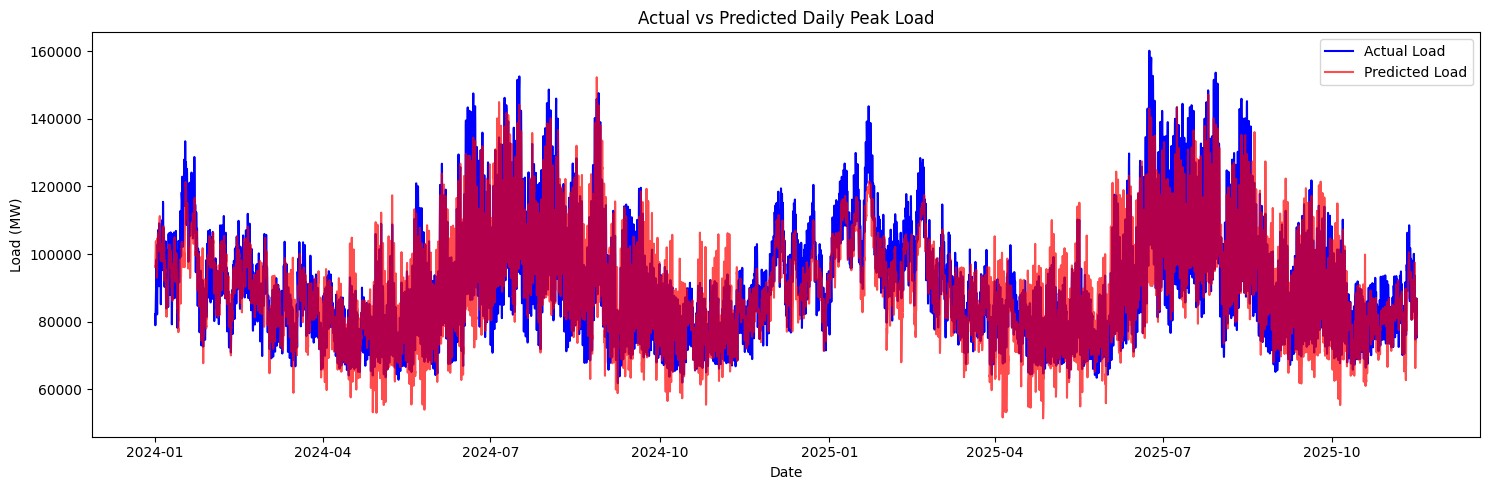

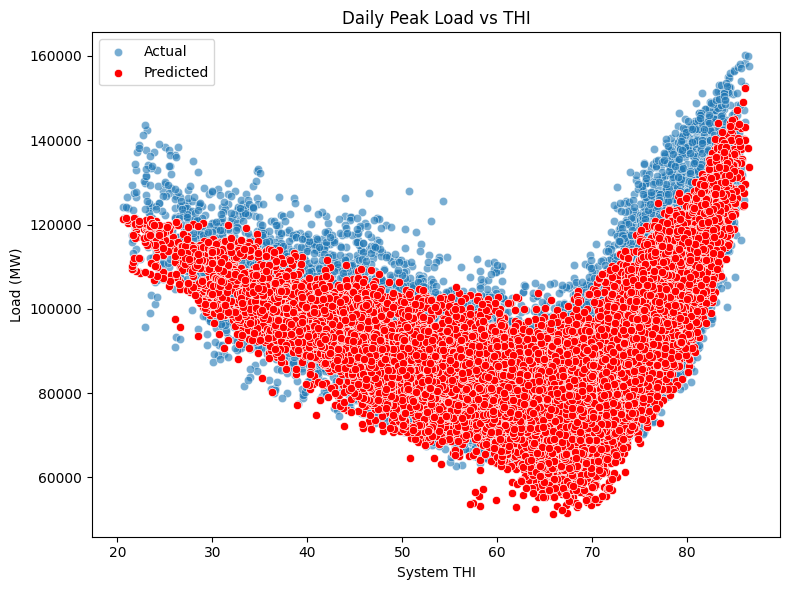

In [25]:
# Create a DataFrame for plotting
plot_df = test_df[['date', 'mw', 'thi']].copy()
plot_df['predicted_mw'] = y_pred

# --- 1. Plot actual vs predicted load over time ---
plt.figure(figsize=(15,5))
plt.plot(plot_df['date'], plot_df['mw'], label='Actual Load', color='blue')
plt.plot(plot_df['date'], plot_df['predicted_mw'], label='Predicted Load', color='red', alpha=0.7)
plt.title('Actual vs Predicted Daily Peak Load')
plt.xlabel('Date')
plt.ylabel('Load (MW)')
plt.legend()
plt.tight_layout()
plt.show()

# --- 2. Scatter plot: THI vs Load with predicted fit ---
plt.figure(figsize=(8,6))
sns.scatterplot(x='thi', y='mw', data=plot_df, label='Actual', alpha=0.6)
sns.scatterplot(x='thi', y='predicted_mw', data=plot_df, label='Predicted', color='red')
plt.title('Daily Peak Load vs THI')
plt.xlabel('System THI')
plt.ylabel('Load (MW)')
plt.legend()
plt.tight_layout()
plt.show()

#### Regression 2: 90th percentile

In [26]:
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

# 2. Fit quantile regression (e.g., 90th percentile)
quantile = 0.75
model = sm.QuantReg(y_train, X_train_sm)
res = model.fit(q=quantile)

print(res.summary())

# 3. Predict on test set
y_pred_q90 = res.predict(X_test_sm)

# 4. Optionally, evaluate performance
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred_q90)
rmse = mse**0.5
print(f"Test RMSE: {rmse:.2f}")


                         QuantReg Regression Results                          
Dep. Variable:                     mw   Pseudo R-squared:               0.4878
Model:                       QuantReg   Bandwidth:                       785.0
Method:                 Least Squares   Sparsity:                    2.583e+04
Date:                Mon, 08 Dec 2025   No. Observations:               105192
Time:                        21:48:49   Df Residuals:                   105157
                                        Df Model:                           34
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
thi             1361.7296      2.767    492.114      0.000    1356.306    1367.153
m_2              891.9580     97.284      9.169      0.000     701.283    1082.633
m_3            -1083.3137    102.838    -10.534      0.000   -1284.874    -881.753
m_4            -4292.8811     79

C:\Users\henry\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\regression\quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
C:\Users\henry\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(eigvals[0]/eigvals[-1])


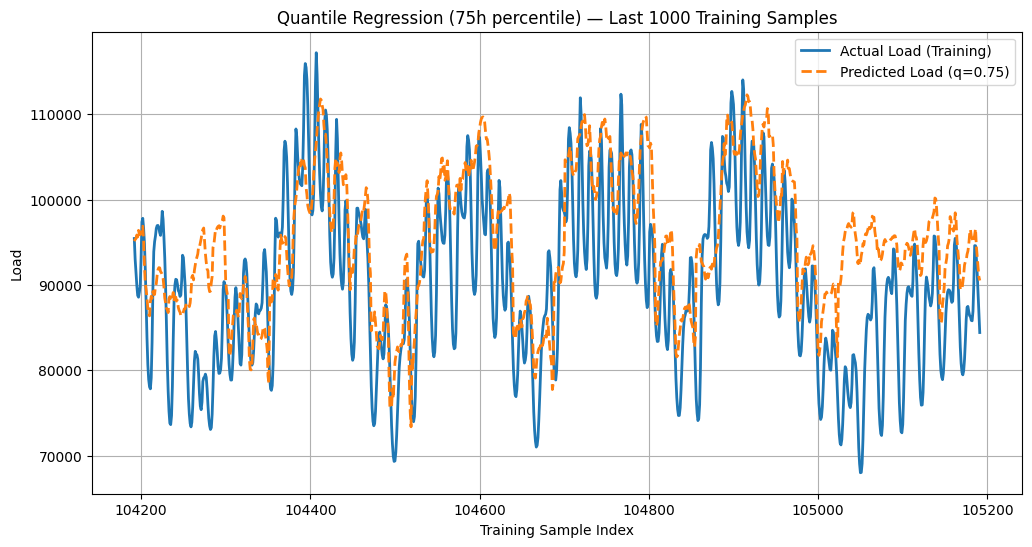

In [27]:
# 1. Predict on the *training* data
y_pred_train_q90 = res.predict(X_train_sm)

# 2. Turn into a Series with the SAME index as y_train
y_pred_train_q90 = pd.Series(y_pred_train_q90, index=y_train.index)

# 3. Take the last 1000 samples
y_train_last = y_train.tail(1000)
y_pred_last = y_pred_train_q90.tail(1000)

# 4. Plot
plt.figure(figsize=(12,6))
plt.plot(y_train_last, label='Actual Load (Training)', linewidth=2)
plt.plot(y_pred_last, label='Predicted Load (q=0.75)', linestyle='--', linewidth=2)

plt.title('Quantile Regression (75h percentile) — Last 1000 Training Samples')
plt.xlabel('Training Sample Index')
plt.ylabel('Load')
plt.grid(True)
plt.legend()
plt.show()


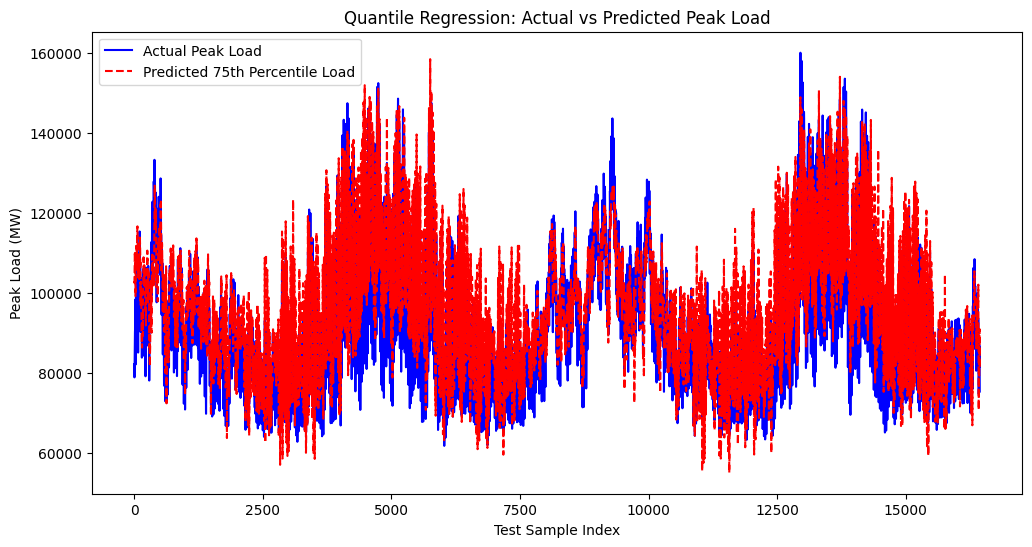

In [28]:
y_test_reset = y_test.reset_index(drop=True)
y_pred_q90_reset = pd.Series(y_pred_q90).reset_index(drop=True)

plt.figure(figsize=(12,6))
plt.plot(y_test_reset, label='Actual Peak Load', color='blue')
plt.plot(y_pred_q90_reset, label='Predicted 75th Percentile Load', color='red', linestyle='--')
plt.xlabel('Test Sample Index')
plt.ylabel('Peak Load (MW)')
plt.title('Quantile Regression: Actual vs Predicted Peak Load')
plt.legend()
plt.show()


Looks to me like the peaks are better approximated by the 75th percentile one 

#### Regression 3: Predictive

In [29]:
from sklearn.ensemble import GradientBoostingRegressor

# 90th percentile quantile regression
gbr_q75 = GradientBoostingRegressor(loss='quantile', alpha=0.75,
                                    n_estimators=500, max_depth=3,
                                    learning_rate=0.05, min_samples_leaf=9)

gbr_q75.fit(X_train, y_train)  # your features, no need for add_constant

# predict
y_pred_train_q75 = gbr_q75.predict(X_train)
y_pred_test_q75  = gbr_q75.predict(X_test)


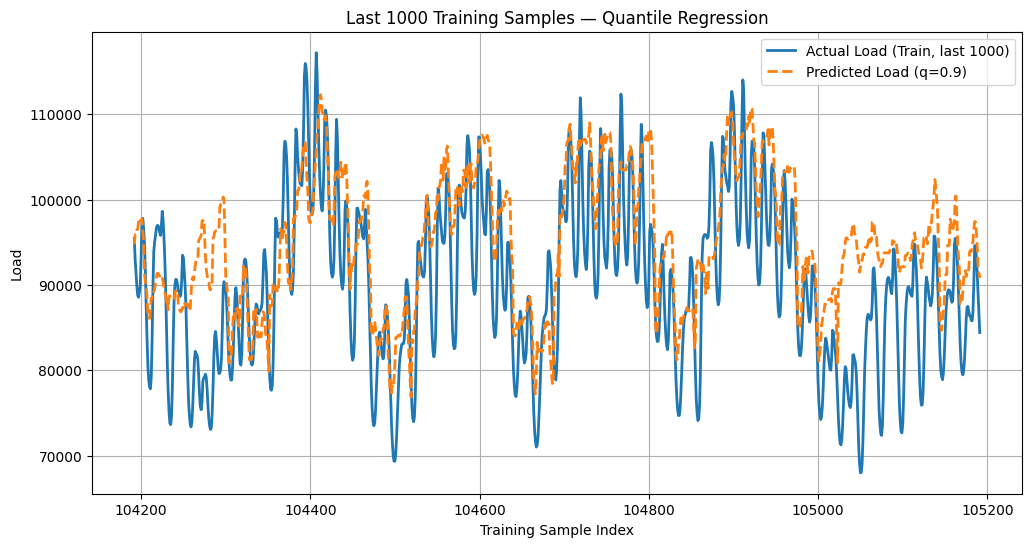

In [31]:
y_pred_train_q75_series = pd.Series(y_pred_train_q75, index=y_train.index)

y_train_last = y_train.tail(1000)
y_pred_last  = y_pred_train_q75_series.tail(1000)

plt.figure(figsize=(12,6))
plt.plot(y_train_last, label='Actual Load (Train, last 1000)', linewidth=2)
plt.plot(y_pred_last, label='Predicted Load (q=0.9)', linestyle='--', linewidth=2)
plt.title('Last 1000 Training Samples — Quantile Regression')
plt.xlabel('Training Sample Index')
plt.ylabel('Load')
plt.grid(True)
plt.legend()
plt.show()


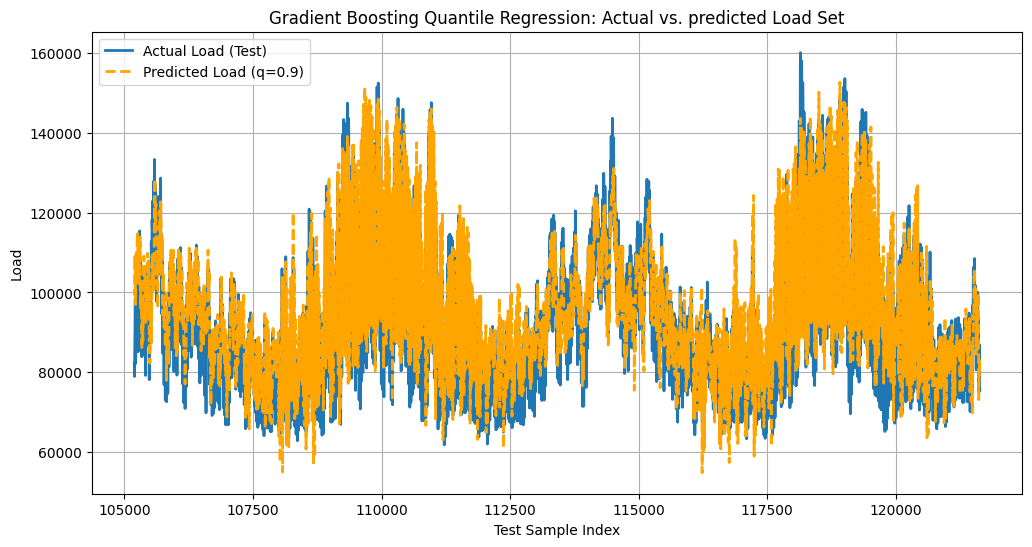

In [33]:
y_pred_test_q75_series = pd.Series(y_pred_test_q75, index=y_test.index)

plt.figure(figsize=(12,6))
plt.plot(y_test, label='Actual Load (Test)', linewidth=2)
plt.plot(y_pred_test_q75_series, label='Predicted Load (q=0.9)', linestyle='--', linewidth=2, color='orange')
plt.title('Gradient Boosting Quantile Regression: Actual vs. predicted Load Set')
plt.xlabel('Test Sample Index')
plt.ylabel('Load')
plt.grid(True)
plt.legend()
plt.show()


## Apply to full weather set 

### Database Pull

In [102]:
# --- Load weather data ---
weather_db_path = "1. Weather/weather_data_2.db"
weather_conn = sqlite3.connect(weather_db_path)

# List tables in the database to see what to load
weather_tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", weather_conn)
print("Weather DB tables:", weather_tables)

# Replace 'system_weather_daily' with the table you actually want
weather_m6 = pd.read_sql("SELECT * FROM system_weather_hourly_minus6;", weather_conn)
weather_m5 = pd.read_sql("SELECT * FROM system_weather_hourly_minus5;", weather_conn)
weather_m4 = pd.read_sql("SELECT * FROM system_weather_hourly_minus4;", weather_conn)
weather_m3 = pd.read_sql("SELECT * FROM system_weather_hourly_minus3;", weather_conn)
weather_m2 = pd.read_sql("SELECT * FROM system_weather_hourly_minus2;", weather_conn)
weather_m1 = pd.read_sql("SELECT * FROM system_weather_hourly_minus1;", weather_conn)
weather_0 = pd.read_sql("SELECT * FROM system_weather_hourly;", weather_conn)
weather_p1 = pd.read_sql("SELECT * FROM system_weather_hourly_plus1;", weather_conn)
weather_p2 = pd.read_sql("SELECT * FROM system_weather_hourly_plus2;", weather_conn)
weather_p3 = pd.read_sql("SELECT * FROM system_weather_hourly_plus3;", weather_conn)
weather_p4 = pd.read_sql("SELECT * FROM system_weather_hourly_plus4;", weather_conn)
weather_p5 = pd.read_sql("SELECT * FROM system_weather_hourly_plus5;", weather_conn)
weather_p6 = pd.read_sql("SELECT * FROM system_weather_hourly_plus6;", weather_conn)

weather_conn.close()

print(weather_0.head())



Weather DB tables:                             name
0                 hourly_weather
1          system_weather_hourly
2   system_weather_hourly_minus6
3   system_weather_hourly_minus5
4   system_weather_hourly_minus4
5   system_weather_hourly_minus3
6   system_weather_hourly_minus2
7   system_weather_hourly_minus1
8    system_weather_hourly_plus1
9    system_weather_hourly_plus2
10   system_weather_hourly_plus3
11   system_weather_hourly_plus4
12   system_weather_hourly_plus5
13   system_weather_hourly_plus6
                        date  system_max_thi
0  1993-06-01 00:00:00+00:00       70.389621
1  1993-06-01 01:00:00+00:00       69.858066
2  1993-06-01 02:00:00+00:00       69.498836
3  1993-06-01 03:00:00+00:00       69.192772
4  1993-06-01 04:00:00+00:00       69.112543


In [88]:
# Add dummies 
weather_dfs = [weather_m6, weather_m5, weather_m4, weather_m3,
               weather_m2, weather_m1, weather_0,
               weather_p1, weather_p2, weather_p3,
               weather_p4, weather_p5, weather_p6]

# Loop through each dataframe
for i, df in enumerate(weather_dfs):
    
    # --- Dates ---
    df['date'] = pd.to_datetime(df['date'])
    df['month'] = df['date'].dt.month
    df['weekday'] = df['date'].dt.day_name()
    
    # --- Weekday dummies ---
    weekday_dummies = pd.get_dummies(df['weekday'], prefix='w', drop_first=True)
    
    # --- Month dummies (for regression) ---
    month_dummies = pd.get_dummies(df['month'], prefix='m', drop_first=True)
    
    # --- Month walk variables ---
    month_walk_dummies = pd.get_dummies(df['month'], prefix='m', drop_first=False)
    month_walk = month_walk_dummies.cumsum(axis=1)
    month_walk.columns = ['m1_w','m2_w','m3_w','m4_w','m5_w','m6_w',
                          'm7_w','m8_w','m9_w','m10_w','m11_w','m12_w']
    
    # --- Merge dummies into df ---
    df = pd.concat([df, month_dummies, month_walk, weekday_dummies], axis=1)
    
    # --- Holidays --- 
    for h in holidays:
        df[h] = 0
    
    # Build holiday dictionary for the dataframe's year range
    start_year = df['date'].dt.year.min()
    end_year = df['date'].dt.year.max()
    hol_dict = build_holidays(start_year, end_year)  # you already have this function
    
    # Set holiday flags to 1 based on actual dates
    for h in holidays:
        if h in hol_dict:
            df[h] = df['date'].isin(pd.to_datetime(hol_dict[h])).astype(int)
    
    # --- Day before / day after holiday ---
    holiday_dates = df.loc[df[holidays].any(axis=1), 'date']
    day_before_holidays = holiday_dates - pd.Timedelta(days=1)
    day_after_holidays  = holiday_dates + pd.Timedelta(days=1)
    df['WkdayBeforeHol'] = df['date'].isin(pd.to_datetime(day_before_holidays)).astype(int)
    df['WkdayAfterHol']  = df['date'].isin(pd.to_datetime(day_after_holidays)).astype(int)
    
    # --- Week after New Year ---
    ny_dates = df.loc[df['NYDay'] == 1, 'date']
    week_after_ny = ny_dates.apply(lambda d: pd.date_range(d + pd.Timedelta(days=1),
                                                           d + pd.Timedelta(days=7))).explode()
    df['WkAfterNewYear'] = df['date'].isin(pd.to_datetime(week_after_ny)).astype(int)
    
    # --- Week before Christmas ---
    xmas_dates = df.loc[df['XmasDay'] == 1, 'date']
    week_before_xmas = xmas_dates.apply(lambda d: pd.date_range(d - pd.Timedelta(days=7),
                                                                d - pd.Timedelta(days=1))).explode()
    df['WkBeforeXMas']   = df['date'].isin(pd.to_datetime(week_before_xmas)).astype(int)
    
    # --- HD/CD and month-specific interactions ---
    df['HD'] = (65 - df['system_max_thi']).clip(lower=0)
    df['CD'] = (df['system_max_thi'] - 65).clip(lower=0)
    df['CD_May'] = df['CD'] * (df['month'] == 5)
    df['HD_Oct'] = df['HD'] * (df['month'] == 10)
    
        # --- Create COVID phase columns ---
    df['phase1'] = 0
    df['phase2'] = 0
    df['phase3'] = 0

    df.loc[(df['date'] >= pd.Timestamp('2020-03-01', tz='UTC')) & 
        (df['date'] <= pd.Timestamp('2020-06-30', tz='UTC')), 'phase1'] = 1

    df.loc[(df['date'] >= pd.Timestamp('2020-06-01', tz='UTC')) & 
        (df['date'] <= pd.Timestamp('2020-11-30', tz='UTC')), 'phase2'] = 1

    df.loc[(df['date'] >= pd.Timestamp('2020-11-01', tz='UTC')) & 
        (df['date'] <= pd.Timestamp('2021-03-31', tz='UTC')), 'phase3'] = 1
    
    # Assign back to list
    weather_dfs[i] = df


# Example check
print(weather_dfs[0].columns.to_list())


['date', 'system_max_thi', 'month', 'weekday', 'm_2', 'm_3', 'm_4', 'm_5', 'm_6', 'm_7', 'm_8', 'm_9', 'm_10', 'm_11', 'm_12', 'm1_w', 'm2_w', 'm3_w', 'm4_w', 'm5_w', 'm6_w', 'm7_w', 'm8_w', 'm9_w', 'm10_w', 'm11_w', 'm12_w', 'w_Monday', 'w_Saturday', 'w_Sunday', 'w_Thursday', 'w_Tuesday', 'w_Wednesday', 'MLK', 'PresDay', 'GoodFri', 'MemDay', 'July4', 'LaborDay', 'Thanks', 'FriAThanks', 'XmasEve', 'XmasDay', 'NYEve', 'NYDay', 'SpringDST', 'FallDST', 'WkdayBeforeHol', 'WkdayAfterHol', 'WkAfterNewYear', 'WkBeforeXMas', 'HD', 'CD', 'CD_May', 'HD_Oct', 'phase1', 'phase2', 'phase3']


In [103]:
for i, df in enumerate(weather_dfs):
    df = df.copy()
    
    # --- Make sure date, month, weekday exist ---
    df['date'] = pd.to_datetime(df['date'])
    df['month'] = df['date'].dt.month
    df['weekday'] = df['date'].dt.weekday  # Monday=0, Sunday=6
    
    # --- Compute HD/CD ---
    df['HD'] = (65 - df['system_max_thi']).clip(lower=0)
    df['CD'] = (df['system_max_thi'] - 65).clip(lower=0)

    # --- Heating/cooling bins ---
    df['HD1'] = df['HD'].clip(upper=10)
    df['HD2'] = (df['HD'] - 10).clip(lower=0, upper=10)
    df['HD3'] = (df['HD'] - 20).clip(lower=0)

    df['CD1'] = df['CD'].clip(upper=5)
    df['CD2'] = (df['CD'] - 5).clip(lower=0, upper=10)
    df['CD3'] = (df['CD'] - 15).clip(lower=0)

    # --- Seasonal HD/CD ---
    df['SpringHD'] = df['HD'] * df['month'].isin([3,4,5])
    df['FallHD']   = df['HD'] * df['month'].isin([9,10,11])
    df['SpringCD'] = df['CD'] * df['month'].isin([3,4,5])
    df['FallCD']   = df['CD'] * df['month'].isin([9,10,11])

    # --- Weekend HD/CD ---
    df['WkEndHD'] = df['HD'] * df['weekday'].isin([5,6])
    df['WkEndCD'] = df['CD'] * df['weekday'].isin([5,6])

    # --- Lag features ---
    df['Lag6HD'] = df['HD'].shift(6)
    df['Lag6CD'] = df['CD'].shift(6)
    df['Lag24HD'] = df['HD'].shift(24)
    df['Lag24CD'] = df['CD'].shift(24)
    df['Lag24HD_CD'] = df['Lag24HD'] * df['Lag24CD']

    # --- Fill missing lag values ---
    df[['Lag6HD','Lag6CD','Lag24HD','Lag24CD','Lag24HD_CD']] = \
        df[['Lag6HD','Lag6CD','Lag24HD','Lag24CD','Lag24HD_CD']].fillna(0)

    # --- Assign back ---
    weather_dfs[i] = df


In [109]:
weather_load_dfs = []

for i, df in enumerate(weather_dfs):
    df = df.copy()  # safer
    
    # Drop 'county' if present
    if 'county' in df.columns:
        df.drop(columns='county', inplace=True)
    
    # Rename column
    df.rename(columns={'system_thi': 'thi'}, inplace=True)
        
    # Predict load
    feature_cols = gbr_q75.feature_names_in_  # list of all features used during training
    df = df.rename(columns={'system_max_thi': 'thi'})

    df['load'] = gbr_q75.predict(df[feature_cols])
    df['season'] = np.where(
        df['month'].isin(list(range(0, 5)) + list(range(10, 12))),
        "Winter",
        "Summer"
)

    result_cols = ['season', 'date', 'thi', 'load']
    result_df = df[result_cols].copy()

    # Save back
    weather_load_dfs.append(result_df)

print(weather_load_dfs[1].head())


['thi' 'm_2' 'm_3' 'm_4' 'm_5' 'm_6' 'm_7' 'm_8' 'm_9' 'm_10' 'm_11'
 'm_12' 'm1_w' 'm2_w' 'm3_w' 'm4_w' 'm5_w' 'm6_w' 'm7_w' 'm8_w' 'm9_w'
 'm10_w' 'm11_w' 'm12_w' 'w_Monday' 'w_Saturday' 'w_Sunday' 'w_Thursday'
 'w_Tuesday' 'w_Wednesday' 'MLK' 'PresDay' 'GoodFri' 'MemDay' 'July4'
 'LaborDay' 'Thanks' 'FriAThanks' 'XmasEve' 'XmasDay' 'NYEve' 'NYDay'
 'SpringDST' 'FallDST' 'WkdayBeforeHol' 'WkdayAfterHol' 'WkAfterNewYear'
 'WkBeforeXMas' 'phase1' 'phase2' 'phase3' 'HD' 'CD' 'HD1' 'HD2' 'HD3'
 'CD1' 'CD2' 'CD3' 'SpringHD' 'FallHD' 'SpringCD' 'FallCD' 'WkEndHD'
 'WkEndCD' 'Lag6HD' 'Lag6CD' 'Lag24HD' 'Lag24CD' 'Lag24HD_CD']
Index(['date', 'thi', 'month', 'weekday', 'm_2', 'm_3', 'm_4', 'm_5', 'm_6',
       'm_7', 'm_8', 'm_9', 'm_10', 'm_11', 'm_12', 'm1_w', 'm2_w', 'm3_w',
       'm4_w', 'm5_w', 'm6_w', 'm7_w', 'm8_w', 'm9_w', 'm10_w', 'm11_w',
       'm12_w', 'w_Monday', 'w_Saturday', 'w_Sunday', 'w_Thursday',
       'w_Tuesday', 'w_Wednesday', 'MLK', 'PresDay', 'GoodFri', 'MemDay',
   

In [112]:
db_path = "load_cases.db"

# Connect (creates file if it doesn't exist)
conn = sqlite3.connect(db_path)
cur = conn.cursor()

# Optional: clear database if tables already exist
cur.execute("DROP TABLE IF EXISTS table_name")  # do this for each table if needed

# Table names for your 13 dataframes
table_names = [
    'weather_m6', 'weather_m5', 'weather_m4', 'weather_m3', 'weather_m2', 'weather_m1',
    'weather_0',
    'weather_p1', 'weather_p2', 'weather_p3', 'weather_p4', 'weather_p5', 'weather_p6'
]

# Loop through dataframes and write to SQLite
for df, table_name in zip(weather_load_dfs, table_names):
    # Write dataframe to SQL (replace table if it exists)
    df.to_sql(table_name, conn, if_exists='replace', index=False)
    print(f"Written table: {table_name}, {len(df)} rows")

# Commit and close
conn.commit()
conn.close()


Written table: weather_m6, 284544 rows
Written table: weather_m5, 284544 rows
Written table: weather_m4, 284544 rows
Written table: weather_m3, 284544 rows
Written table: weather_m2, 284544 rows
Written table: weather_m1, 284544 rows
Written table: weather_0, 284544 rows
Written table: weather_p1, 284544 rows
Written table: weather_p2, 284544 rows
Written table: weather_p3, 284544 rows
Written table: weather_p4, 284544 rows
Written table: weather_p5, 284544 rows
Written table: weather_p6, 284544 rows


In [113]:
# Connect to your database
db_path = "load_cases.db"
conn = sqlite3.connect(db_path)

# 1️⃣ List all tables in the database
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print("Tables in the database:")
print(tables)

# 2️⃣ Preview the first few rows of one table (e.g., weather_0)
df_test = pd.read_sql("SELECT * FROM weather_0 LIMIT 5;", conn)
print("\nFirst 5 rows of weather_0:")
print(df_test)

# Close connection when done
conn.close()


Tables in the database:
          name
0   weather_m6
1   weather_m5
2   weather_m4
3   weather_m3
4   weather_m2
5   weather_m1
6    weather_0
7   weather_p1
8   weather_p2
9   weather_p3
10  weather_p4
11  weather_p5
12  weather_p6

First 5 rows of weather_0:
   season                       date        thi          load
0  Summer  1993-06-01 00:00:00+00:00  70.389621  95954.689559
1  Summer  1993-06-01 01:00:00+00:00  69.858066  95301.481007
2  Summer  1993-06-01 02:00:00+00:00  69.498836  95114.095027
3  Summer  1993-06-01 03:00:00+00:00  69.192772  94900.807633
4  Summer  1993-06-01 04:00:00+00:00  69.112543  94531.000259
